Convert wo CV metadata

- pixel spacing
  - xy: from tif file
  - z: from MeasurementProtocol.xml
    -     <icm:ZSetting icm:Range="76.5000" icm:Slices="10" icm:BottomAbs_um="-25.8000" />

- channels: manually
- shapes: from tif file
- FOV center positions: from measurementprotocol.xml
      <icm:Well icm:UniqueID="203" icm:Number="4" icm:Column="4" icm:Row="1" icm:IsIgnore="false" icm:IsEnabled="true" icm:IsAnalysis="false">
        <icm:CenterCoord icm:X="-22.48" icm:Y="32.06" />
        <icm:Areas />
      </icm:Well>
- image data: from tiff files


In [1]:
from pathlib import Path
import os
import tifffile

# scu_analysis_dir = Path("/Volumes/scuanalysis")
scu_analysis_dir = Path("/links/shared/scuanalysis")

# input_dir = scu_analysis_dir / "LAF/Sant/P2001_Hierlemann_00013516_wo_CV_format/20251027T132950_10X"
# input_dir = scu_analysis_dir / "Hierlemann/carolina/Yokogawa_CQ3000/20250729T171334_20X_dry_ST2036Q10W"
input_dir = scu_analysis_dir / "Hierlemann/carolina/Yokogawa_CQ3000/20250729T171334_20X_dry_ST2036Q10W"
input_dir = scu_analysis_dir / "Hierlemann/carolina/Yokogawa_CQ3000/P2013_Hierlemann_00013586/20251212T014449_20X_W"
input_dir

PosixPath('/links/shared/scuanalysis/Hierlemann/carolina/Yokogawa_CQ3000/P2013_Hierlemann_00013586/20251212T014449_20X_W')

In [2]:
ls /links/shared/scuanalysis/Hierlemann/carolina/Yokogawa_CQ3000/P2013_Hierlemann_00013586/20251212T014449_20X_W

 00013586.mes*
 00013586.ome.tif*
 00013586.ome.xml*
 00013586.wpi*
 00013586_MIP.ome.tif*
 00013586_MIP.ome.xml*
'10_Greiner_μClear #655090.wpp'*
 Base_Yokogawa_CQMicroplateEnviroment.xml*
 Calibration/
 EnvironmentControlParameter.xml*
 EquipmentConfiguration.xml*
 Image/
 ImageViewSetting.xml*
 ImagingResult.xml*
 Log/
'MP_Greiner_SensoPlate #655090.xml'*
 MeasurementData.mlf*
 MeasurementDescription.xml*
 MeasurementDetail.mrf*
 MeasurementProtocol.xml*
 MeasurementProtocol.xslt*
 ORCA_Flash_40.xml*
 OutputImageInfo.xml*
 Projection/


In [3]:
import xmltodict

ome_dict = xmltodict.parse(open(
    # input_dir / "MeasurementResult.ome.xml"
    input_dir / "00013586.ome.xml"
).read()
)

In [4]:
well_dicts_non_empty = [well for well in ome_dict['OME']['Plate']['Well'] if 'WellSample' in well]
well_indices = [int(well['@ID'].split(':')[1]) for well in well_dicts_non_empty]
well_rows = [chr(ord('A') + int(well_dict['@Row']) - 1) for well_dict in well_dicts_non_empty]
well_cols = [str(well_dict['@Column']) for well_dict in well_dicts_non_empty]
fov_positions = [
    [
        {
            'x': float(fov_dict['@PositionX']),
            'y': float(fov_dict['@PositionY']),
        }
        for fov_dict in well_dict['WellSample']
    ]
    for well_dict in well_dicts_non_empty[:]
    ]
# fov_positions[10]
well_indices

[13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81]

In [8]:
wells_indices_to_write = well_indices[:1]
wells_indices_to_write

[13]

In [16]:
ls /links/shared/scuanalysis/ome-zarr-tests/P2013_Hierlemann_00013586_ome/test.ome.zarr

A/


## Create plate metadata

In [9]:
from ngio import ImageInWellPath, create_empty_plate

# output_base = Path("/local1/albertm/ome-zarr-tests")
output_base = Path("/links/shared/scuanalysis/ome-zarr-tests/P2013_Hierlemann_00013586_ome")

output_zarr_path = output_base / "test.ome.zarr"

test_plate = create_empty_plate(
    store=output_zarr_path,
    name="Test Plate",
    images=[

        # no stitching
        # ImageInWellPath(row=row, column=col, path=str(field_index))
        # for iwell, (row, col) in enumerate(zip(well_rows, well_cols))
        # for field_index, _ in enumerate(fov_positions[iwell][:10])

        # stitching
        ImageInWellPath(
            row=well_rows[well_indices.index(well_index)],
            column=well_cols[well_indices.index(well_index)],
            path="0")
        # for iwell, (row, col) in enumerate(zip(well_rows, well_cols))
        for well_index in wells_indices_to_write
    ],
    overwrite=True,
)

print(test_plate)
print(f"Rows: {test_plate.rows}, Columns: {test_plate.columns}")

Plate([rows x columns] (1 x 1))
Rows: ['A'], Columns: ['1']


## Write images

In [10]:
# sort images by well

well_image_dicts = {}
for image in ome_dict['OME']['Image'][:]:
    if image['@Name'] == 'TitleImage': continue
    well_index = int(image['@Name'].split('(')[0][1:]) - 1
    if well_index not in well_image_dicts:
        well_image_dicts[well_index] = []
    well_image_dicts[well_index].append(image)
    # print(well_index)

# for well, images in well_image_dicts.items():
#     print(f"Well {well}: {len(images)} images")

In [11]:
import dask.array as da
from dask import delayed
import xarray as xr
import numpy as np

from multiview_stitcher import spatial_image_utils as si_utils
from multiview_stitcher import io, vis_utils, fusion, misc_utils

# iterate wells
for iiwell, (well_index, image_list) in enumerate(well_image_dicts.items()):
    if well_index not in wells_indices_to_write:
        continue

    row, col = (
        well_rows[well_indices.index(well_index)],
        well_cols[well_indices.index(well_index)],
    )

    # iterate FOVs
    sims = []
    for iimage, image in enumerate(image_list[:]):

        # if iimage not in [0, 1, 2, 3, 10, 11, 12, 13]: continue

        spacing = {
            'x': float(image['Pixels']['@PhysicalSizeX']),
            'y': float(image['Pixels']['@PhysicalSizeY']),
            'z': float(image['Pixels']['@PhysicalSizeZ']),
        }
        shape = {
            'x': int(image['Pixels']['@SizeX']),
            'y': int(image['Pixels']['@SizeY']),
            'z': int(image['Pixels']['@SizeZ']),
        }
        dtype=image['Pixels']['@Type']

        print(image['@Name'], shape, spacing, dtype)
        # print(image['@Name'], shape, spacing, dtype)

        # iterate planes
        xims = {}
        for i, (tifdata, plane) in enumerate(
            zip(
                image['Pixels']['TiffData'],
                image['Pixels']['Plane']
            )):
            # print((tifdata, plane))

            data = da.from_delayed(
                delayed(tifffile.imread)(
                        input_dir / tifdata['UUID']['@FileName']
                ),
                shape=[shape[dim] for dim in ['y', 'x']],
            dtype=dtype,
            )

            data = data[None] # add z dimension
            data = data[None] # add c dimension

            z = int(plane['@TheZ'])
            c = int(plane['@TheC'])

            xim = xr.DataArray(
                data,
                dims=['c', 'z', 'y', 'x'],
                coords={
                    'z': [z],
                    'c': [c]
                },
            )

            # flip y axis
            # xim.data = xim.data[:, :, ::-1, :]

            if c not in xims:
                xims[c] = xim
            else:
                xims[c] = xims[c].combine_first(xim)

        xim = xr.concat(xims.values(), dim='c')

        # xim = xr.combine_by_coords(xims, join='outer').to_array()
        sim = si_utils.get_sim_from_array(
            xim.data,
            dims =xim.dims,
            scale=spacing,
            translation={
                dim: float(plane[f'@Position{dim.upper()}']) * [1, -1][dim=='y']
                for dim in ['x', 'y', 'z']
            }
        )
        sims.append(sim)
    
    fused = fusion.fuse(
        # [msi_utils.get_msim_from_sim(s, scale_factors=[]) for s in sims],
        sims,
        transform_key = io.METADATA_TRANSFORM_KEY,
        output_chunksize={'z': 1, 'c': 1, 'y': 2000, 'x': 2000},
        output_zarr_url=output_zarr_path / row / col / "0",
        zarr_options={
            'ome_zarr': True,
        },
        batch_options={
            'n_batch': 500,
            'batch_func': misc_utils.process_batch_using_joblib,
            'batch_func_kwargs': {
                'n_jobs': 50,
            },
        },
    )

W14(R2C2),A1,F1 {'x': 2000, 'y': 2000, 'z': 7} {'x': 0.3237697, 'y': 0.3237697, 'z': 5.714286} uint16
W14(R2C2),A1,F2 {'x': 2000, 'y': 2000, 'z': 7} {'x': 0.3237697, 'y': 0.3237697, 'z': 5.714286} uint16
W14(R2C2),A1,F3 {'x': 2000, 'y': 2000, 'z': 7} {'x': 0.3237697, 'y': 0.3237697, 'z': 5.714286} uint16
W14(R2C2),A1,F4 {'x': 2000, 'y': 2000, 'z': 7} {'x': 0.3237697, 'y': 0.3237697, 'z': 5.714286} uint16
W14(R2C2),A1,F5 {'x': 2000, 'y': 2000, 'z': 7} {'x': 0.3237697, 'y': 0.3237697, 'z': 5.714286} uint16
W14(R2C2),A1,F6 {'x': 2000, 'y': 2000, 'z': 7} {'x': 0.3237697, 'y': 0.3237697, 'z': 5.714286} uint16
W14(R2C2),A1,F7 {'x': 2000, 'y': 2000, 'z': 7} {'x': 0.3237697, 'y': 0.3237697, 'z': 5.714286} uint16
W14(R2C2),A1,F8 {'x': 2000, 'y': 2000, 'z': 7} {'x': 0.3237697, 'y': 0.3237697, 'z': 5.714286} uint16
W14(R2C2),A1,F9 {'x': 2000, 'y': 2000, 'z': 7} {'x': 0.3237697, 'y': 0.3237697, 'z': 5.714286} uint16
W14(R2C2),A1,F10 {'x': 2000, 'y': 2000, 'z': 7} {'x': 0.3237697, 'y': 0.3237697, '

100%|██████████| 2/2 [06:15<00:00, 187.74s/it]
/local0/albertm/software/CQ3000_converter/.pixi/envs/default/lib/python3.13/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/local0/albertm/software/CQ3000_converter/.pixi/envs/default/lib/python3.13/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Found existing resolution level 0...
Writing resolution level 1...


  0%|          | 0/252 [00:00<?, ?it/s]/local0/albertm/software/CQ3000_converter/.pixi/envs/default/lib/python3.13/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'config'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
100%|██████████| 252/252 [00:46<00:00,  5.40it/s]


Writing resolution level 2...


...

100%|██████████| 28/28 [00:03<00:00,  7.81it/s]


Writing resolution level 8...


100%|██████████| 28/28 [00:02<00:00, 10.11it/s]


Writing resolution level 9...


100%|██████████| 28/28 [00:03<00:00,  8.97it/s]


In [12]:
fused

<xarray.DataArray 'image' (t: 1, c: 4, z: 7, y: 9001, x: 9001)> Size: 9GB
dask.array<from-zarr, shape=(1, 4, 7, 9001, 9001), dtype=float32, chunksize=(1, 1, 1, 2000, 2000), chunktype=numpy.ndarray>
Coordinates:
  * t        (t) int64 8B 0
  * c        (c) int64 32B 0 1 2 3
  * z        (z) float64 56B 25.2 30.91 36.63 42.34 48.06 53.77 59.49
  * y        (y) float64 72kB -2.333e+03 -2.333e+03 -2.333e+03 ... 580.2 580.5
  * x        (x) float64 72kB -2.337e+03 -2.337e+03 -2.337e+03 ... 576.4 576.7
Attributes:
    transforms:  {'affine_metadata': <xarray.DataArray (x_in: 4, x_out: 4)> S...

In [13]:
1

1

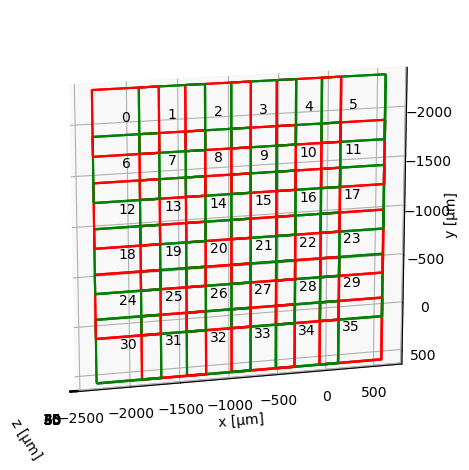

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='z [μm]', ylabel='x [μm]', zlabel='y [μm]'>)

In [14]:
from multiview_stitcher import vis_utils, misc_utils

vis_utils.plot_positions(
    sims, transform_key = io.METADATA_TRANSFORM_KEY
)

In [ ]:
from multiview_stitcher import fusion, msi_utils

fused = fusion.fuse(
    # [msi_utils.get_msim_from_sim(s, scale_factors=[]) for s in sims],
    sims,
    transform_key = io.METADATA_TRANSFORM_KEY,
    output_chunksize={'z': 1, 'c': 1, 'y': 2000, 'x': 2000},
    output_zarr_path=output_zarr_path / 
)